## Importación de librerias, cargado y limpieza de datos

In [ ]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import ast 

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')]

df_DA_US

## Análisis de la demanda de Analistas de Datos en Estados Unidos

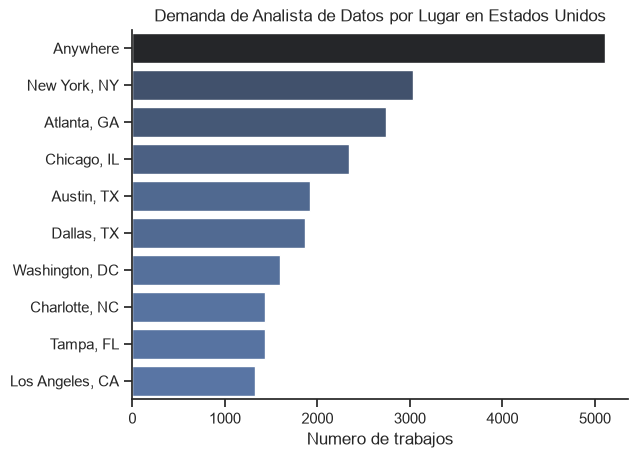

In [8]:
df_plot = df_DA_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Demanda de Analista de Datos por Lugar en Estados Unidos')
plt.xlabel('Numero de trabajos')
plt.ylabel('')
plt.show()

## Análisis de Trabajo Remoto, Requerimiento de Título y Seguro Médico 

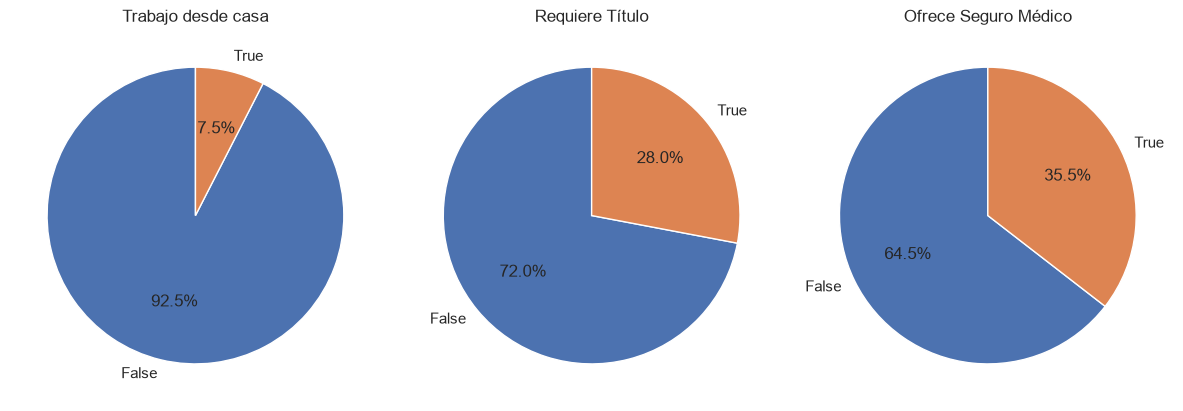

In [9]:
fig, ax = plt.subplots(1, 3)
fig.set_size_inches((12, 5))

dict_column = {
    'job_work_from_home': 'Trabajo desde casa',
    'job_no_degree_mention': 'Requiere Título',
    'job_health_insurance': 'Ofrece Seguro Médico'
}

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_US[column].value_counts(), startangle=90, autopct='%1.1f%%', labels=['False', 'True'])
    ax[i].set_title(title)
fig.tight_layout()
plt.show()


## Top 10 Empresas Buscando Analistas de Datos

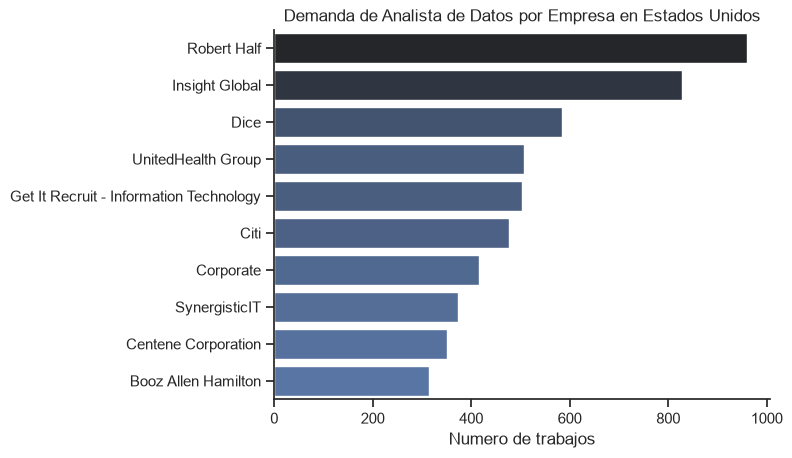

In [10]:
df_plot = df_DA_US['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Demanda de Analista de Datos por Empresa en Estados Unidos')
plt.xlabel('Numero de trabajos')
plt.ylabel('')
plt.show()

## Distribución del salario anual de Analistas de Datos

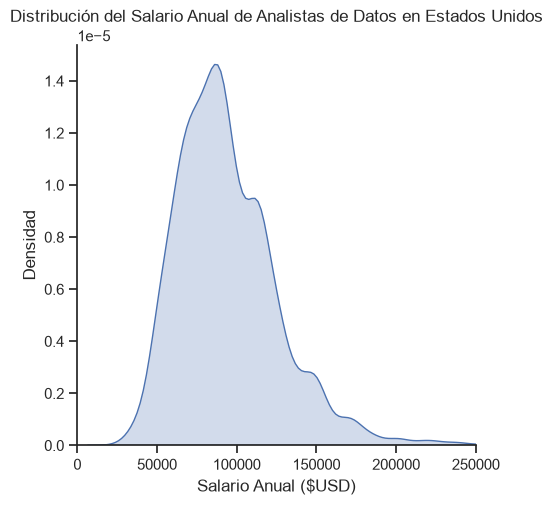

In [11]:
sns.set_theme(style='ticks')
sns.displot(df_DA_US['salary_year_avg'], kind='kde', fill=True)


plt.title('Distribución del Salario Anual de Analistas de Datos en Estados Unidos')

plt.ylabel('Densidad')
plt.xlabel('Salario Anual ($USD)')
plt.xlim(0, 250000)
plt.show()